### American vs Euorpean Options
The key difference between American and European option lies in their boundary coditions.\
Black-Scholes European Option = PDE holds for: 0 $\leq$ $\tau$ $\leq$ T, S > 0 \
Black-Scholes American Option = PDE holds for: 0 $\leq$ $\tau$ $\leq$ T, 0 < S $\leq$ b($\nu$, $\tau$)

Where:\
T = Maturity\
$\tau$ = Time Remaining Until to Maturity\
$\nu$ = Volatility\
b($\nu$, $\tau$) = Critical threshold where if stok price crosses this boundary, the PDE no longer applies because it becomes mathematically optimal to exercise the option immediately rather than continue holding it.

### The Early Excercise Boundary
Barone-Adesi-Whaley(1987), recognizes an American option can be decomposed as:

$C_A = C_E + V$

European Call Price: $C_E$\
Early Exercise Premium: $V$


Numerical Methods to Solve for this Free Boundary:\
- Binomial Trees
- Finit Differences
- Monte Carlo with Regression

When would early excercise become desireable?
1. dividends that the owner of the stock will recieve
2. positive cashflow on interest earned

In the case that there are not dividend/interest considerations, then the value of the american option should equal the value of a European option.

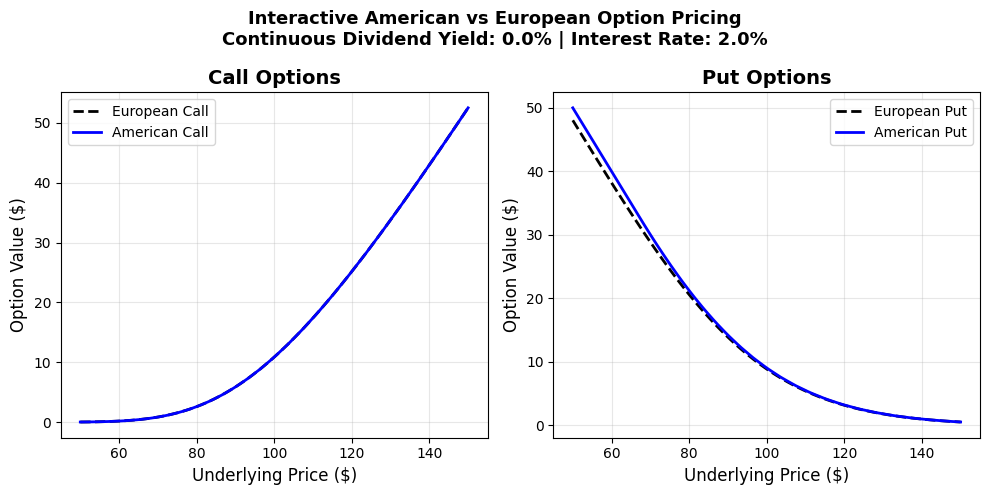

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='Dividend (q):', layout=Layo…

<function __main__.plot_options(q, r)>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import ipywidgets as widgets
# from IPython.display import display

# Black–Scholes European formulas
def bs_call(S, K, r, sigma, T):
    d1 = (np.log(S/K) + (r + 0.5 * sigma**2)*T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)

def bs_put(S, K, r, sigma, T):
    d1 = (np.log(S/K) + (r + 0.5 * sigma**2)*T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# Binomial tree for American option
def american_binomial(S, K, r, sigma, T, N, opt_type="call"):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1/u
    p = (np.exp(r * dt) - d) / (u - d)

    # stock prices
    ST = np.array([S * u**j * d**(N-j) for j in range(N+1)])

    # terminal payoff
    if opt_type == "call":
        V = np.maximum(ST - K, 0)
    else:
        V = np.maximum(K - ST, 0)

    # backward induction
    for i in range(N-1, -1, -1):
        ST = ST[1:] / u  # step down tree
        V = np.exp(-r*dt)*(p*V[1:] + (1-p)*V[:-1])
        intrinsic = (ST - K) if opt_type == "call" else (K - ST)
        V = np.maximum(V, intrinsic)

    return V[0]

# Parameters 
S_range = np.linspace(50, 150, 100)
K = 100
sigma = 0.25
T = 1.0
N = 200

# Create interactive plot function 
def plot_options(q, r):
    # Compute option values
    euro_calls = [bs_call(s, K, r - q, sigma, T) for s in S_range]
    euro_puts = [bs_put(s, K, r - q, sigma, T) for s in S_range]
    
    amer_calls = [american_binomial(s, K, r - q, sigma, T, N, "call") for s in S_range]
    amer_puts = [american_binomial(s, K, r - q, sigma, T, N, "put") for s in S_range]
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # CALLS 
    ax = axes[0]
    ax.plot(S_range, euro_calls, 'k--', label="European Call", linewidth=2)
    ax.plot(S_range, amer_calls, 'b-', label="American Call", linewidth=2)
    ax.set_title("Call Options", fontsize=14, fontweight='bold')
    ax.set_xlabel("Underlying Price ($)", fontsize=12)
    ax.set_ylabel("Option Value ($)", fontsize=12)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # PUTS
    ax = axes[1]
    ax.plot(S_range, euro_puts, 'k--', label="European Put", linewidth=2)
    ax.plot(S_range, amer_puts, 'b-', label="American Put", linewidth=2)
    ax.set_title("Put Options", fontsize=14, fontweight='bold')
    ax.set_xlabel("Underlying Price ($)", fontsize=12)
    ax.set_ylabel("Option Value ($)", fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'Interactive American vs European Option Pricing\nContinuous Dividend Yield: {q:.1%} | Interest Rate: {r:.1%}', 
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Create interactive widgets
q_slider = widgets.FloatSlider(
    value=0.0,
    min=0.0,
    max=0.10,
    step=0.005,
    description='Dividend (q):',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.1%',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='600px')
)

r_slider = widgets.FloatSlider(
    value=0.02,
    min=-0.05,
    max=0.15,
    step=0.005,
    description='Interest Rate (r):',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.1%',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='600px')
)

# --- Display interactive plot ---
widgets.interact(plot_options, q=q_slider, r=r_slider)

In theory, an American call on a non-dividend paying stock is equal to a European call. so the following conditions are when divergence becomes meaningful.
1. Intrinsic value is large (Deep ITM), and holding the call means missing out on dividend yield or holding onto the put meaning missing out on interest
2. High Dividend Yield (q), dividend stream is "carry cost" of holding stock via call.

Early exercise only matters when you gain more by taking the stock now than by keeping your optionality. Whether that's because of dividend considerations or possible interest earned.

### Scenarios
1. For American call options on non-dividend-paying stocks\
There is never a rational reason to exercise early.
2. For American call options on dividend-paying stocks\
Early exercise can be optimal right before an ex-dividend date.
3. For American put options\
Early exercise can many times be optimal.
 
Why Put Options:
- Deep-in-the-money puts behave like debt - by exercising early, you receive cash today rather than later.

- If interest rates are positive, receiving cash sooner can outweigh remaining time value.

- Deep-in-the-money + low volatility + longer maturity increases the chance that early exercise is optimal.

- There's no single "timestamp," but the early-exercise region is well-defined in models like the free-boundary solution of the American PDE.

## Synthetic Data Creation
- Synthetic data will allow us to create features that encompass every economically viable condition found in the market
- Each feature must have a different range, otherwise, the dataset will become over encoimpassing and too large for price generation.
- Since its impossible to combine every possible feature value with eachother sampling is important. We will create five matrices of values one for each feature and combine them to create the dataset.

#### Sampling
Without sampling when generating my dataset every possible increment of a value would need to be included. This is not possible, thus, we use sampling to generate thousands of these combinations automatically. The different methods listed determine whether these values are spread evenly, or are concentrated differently across values.

- **Uniform sampling:** Draws each value with equal probability acrosss the range of values. We use this for parameters who scale lineraly across the range and want none of the value to have more representation in the dataset over others.

- **Log-uniform sampling:** Draws each value with equal probability across log-space. We use this on features that change multiplicatly like volatility. Using something like **Uniform Sampling** would under represent low volatility values which are what is most typically found in regular market conditions.

#### Boundaries:
- **Moneyness (K/S): 0.50 to 1.50** covers deep ITM to deep OTM while excluding sub-0.50 territory where options behave like pure stock positions and add little training signal.

- **Time to Expiry (T): 0.005 to 3.0 years** uses 0.005 (~2 days) as the practical floor before binomial trees become numerically unstable, and 3.0 years captures LEAPS without wasting samples on the 3 to 5 year range where behavior barely changes.

- **Volatility (σ): 0.05 to 1.50** sets 0.05 to reflect the quietest liquid instruments and 1.50 to cover extreme events like biotech binary readouts or meme stocks, capturing the full spectrum of real-world vol regimes the model may encounter.

- **Risk-free rate (r): -0.02 to 0.10** sets -0.02 to reflect the negative rate environment seen in Europe and Japan post-2008, and 0.10 to cover aggressive tightening cycles like 2022 to 2023 without sampling rates that have never existed in modern developed markets.

- **Dividend yield (q): 0.00 to 0.06** spans from zero for growth stocks and non-payers up to 0.06 for the highest-yielding liquid equities with active options markets, ensuring adequate coverage of cases where q > r which triggers rational early exercise on American calls.




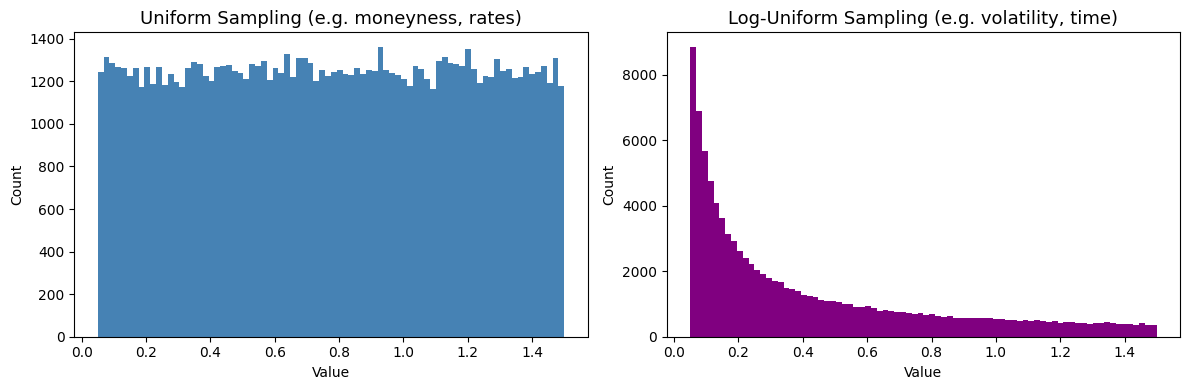

In [2]:
N = 100_000
lo, hi =0.05, 1.50  # using volatility as the example

uniform_samples    = np.random.uniform(lo, hi, N)
log_uniform_samples = np.exp(np.random.uniform(np.log(lo), np.log(hi), N))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(uniform_samples, bins=80, color="steelblue", edgecolor="none")
axes[0].set_title("Uniform Sampling (e.g. moneyness, rates)", fontsize=13)
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")

axes[1].hist(log_uniform_samples, bins=80, color="purple", edgecolor="none")
axes[1].set_title("Log-Uniform Sampling (e.g. volatility, time)", fontsize=13)
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [3]:
import pandas as pd

def generateOptionsGrid(n_random=50000):

    mon_range= (0.50, 1.50)
    time_range= (0.005, 3.0)
    vol_range= (0.05, 1.50)
    rfr_range= (-0.02, 0.10)
    div_range= (0.00, 0.06)

    np.random.seed(42)
    N = n_random

    S = 100.0
    moneyness = np.random.uniform(*mon_range, N)

    data = pd.DataFrame({
        'S':np.full(N, S),
        'K':S * moneyness,
        'T':np.exp(np.random.uniform(np.log(time_range[0]), np.log(time_range[1]), N)),
        'r':np.random.uniform(*rfr_range, N),
        'sigma':np.exp(np.random.uniform(np.log(vol_range[0]), np.log(vol_range[1]), N)),
        'q':np.random.uniform(*div_range, N),
        'option_type': np.random.choice([1, 0], N)
    })

    # Systematic grid to guarantee coverage of key regimes
    moneyness_cases = []
    for m in [0.5, 0.7, 0.8, 0.9, 0.95, 1.0, 1.05, 1.1, 1.2, 1.5]:
        for T in [1/52, 1/12, 0.25, 0.5, 1.0, 2.0]:
            for sigma in [0.1, 0.2, 0.4, 0.8]:
                for r in [0.01, 0.04, 0.07]:
                    moneyness_cases.append({
                        'S': S, 'K': S * m, 'T': T, 'r': r,
                        'sigma': sigma, 'q': 0.02,
                        'option_type': np.random.choice([1, 0])
                    })

    systematic = pd.DataFrame(moneyness_cases)
    df = pd.concat([data, systematic], ignore_index=True)

    return df.reset_index(drop=True)

In [4]:
df = generateOptionsGrid(500000)
df.head(20)

,S,K,T,r,sigma,q,option_type
0,100.0,87.454012,0.033880,0.051419,0.576443,0.006109,0
1,100.0,145.071431,0.130146,0.023766,0.211709,0.017897,1
2,100.0,123.199394,0.307565,-0.019355,0.099072,0.038194,1
3,100.0,109.865848,2.853534,0.047331,0.069293,0.026140,1
4,100.0,65.601864,0.427395,0.087588,0.531824,0.013235,1
5,100.0,65.599452,0.106844,0.043806,0.712437,0.059448,0
6,100.0,55.808361,0.066008,0.073659,0.403205,0.039253,0
7,100.0,136.617615,0.035235,-0.000565,1.273938,0.049212,0
8,100.0,110.111501,0.015287,-0.003524,0.082065,0.054284,1
9,100.0,120.807258,0.033761,0.087273,0.137376,0.008267,0


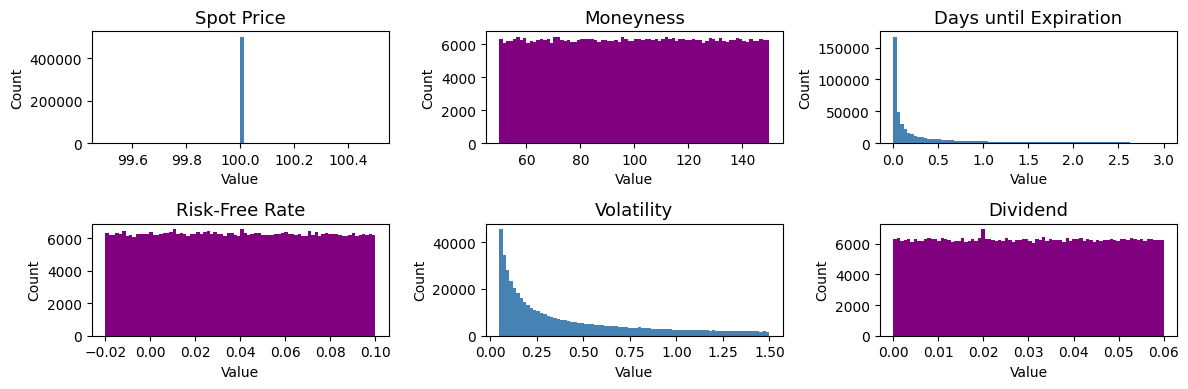

In [5]:


fig, axes = plt.subplots(2, 3, figsize=(12, 4))

axes[0][0].hist(df["S"], bins=80, color="steelblue", edgecolor="none")
axes[0][0].set_title("Spot Price", fontsize=13)
axes[0][0].set_xlabel("Value")
axes[0][0].set_ylabel("Count")

axes[0][1].hist(df["K"], bins=80, color="purple", edgecolor="none")
axes[0][1].set_title("Moneyness", fontsize=13)
axes[0][1].set_xlabel("Value")
axes[0][1].set_ylabel("Count")

axes[0][2].hist(df["T"], bins=80, color="steelblue", edgecolor="none")
axes[0][2].set_title("Days until Expiration", fontsize=13)
axes[0][2].set_xlabel("Value")
axes[0][2].set_ylabel("Count")

axes[1][0].hist(df["r"], bins=80, color="purple", edgecolor="none")
axes[1][0].set_title("Risk-Free Rate", fontsize=13)
axes[1][0].set_xlabel("Value")
axes[1][0].set_ylabel("Count")

axes[1][1].hist(df["sigma"], bins=80, color="steelblue", edgecolor="none")
axes[1][1].set_title("Volatility", fontsize=13)
axes[1][1].set_xlabel("Value")
axes[1][1].set_ylabel("Count")

axes[1][2].hist(df["q"], bins=80, color="purple", edgecolor="none")
axes[1][2].set_title("Dividend", fontsize=13)
axes[1][2].set_xlabel("Value")
axes[1][2].set_ylabel("Count")

plt.tight_layout()
plt.show()

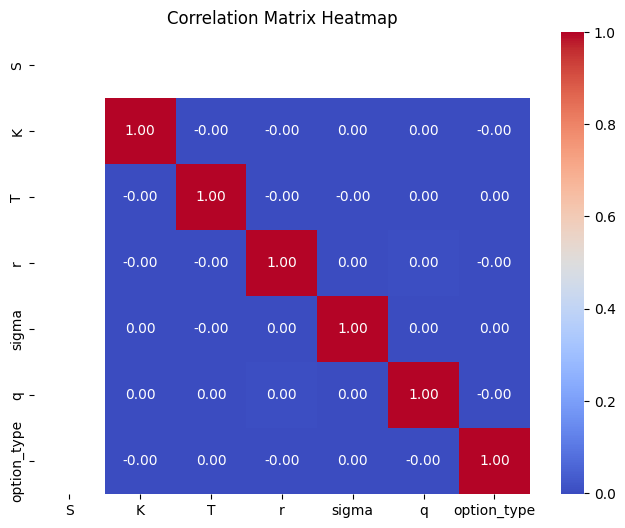

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f") 
plt.title('Correlation Matrix Heatmap')
plt.show()

This signals that none of the features are correlated, which we were hoping to accompkish with this data.

## Lets Compare the Synthetic Data to SPY Options Chain

In [7]:
data = pd.read_csv('archive.zip')
data.head()


/var/folders/1d/t1dpf99x6zsb1vdbgx57d7280000gp/T/ipykernel_45299/3436605266.py:1: DtypeWarning: Columns (8,9,10,11,12,13,15,17,18,20,21,23,24,25,26,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('archive.zip')


,[QUOTE_UNIXTIME],[QUOTE_READTIME],[QUOTE_DATE],[QUOTE_TIME_HOURS],[UNDERLYING_LAST],[EXPIRE_DATE],[EXPIRE_UNIX],[DTE],[C_DELTA],[C_GAMMA],...,[P_LAST],[P_DELTA],[P_GAMMA],[P_VEGA],[P_THETA],[P_RHO],[P_IV],[P_VOLUME],[STRIKE_DISTANCE],[STRIKE_DISTANCE_PCT]
0,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,-0.000240,0.000000,0.000040,-0.005090,0.000000,3.412490,3.000000,181.9,0.402
1,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,-0.000630,0.000030,0.000190,-0.004800,0.000000,3.297370,0.000000,176.9,0.391
2,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,0.000000,0.000000,-0.000230,-0.005340,0.000000,3.183300,11.000000,171.9,0.380
3,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,-0.000160,0.000040,0.000380,-0.005320,0.000000,3.072170,50.000000,166.9,0.369
4,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,-0.000680,0.000000,0.000450,-0.005150,0.000000,2.962300,0.000000,161.9,0.358


In [8]:
pd.set_option('display.max_columns', None)
data.head()

,[QUOTE_UNIXTIME],[QUOTE_READTIME],[QUOTE_DATE],[QUOTE_TIME_HOURS],[UNDERLYING_LAST],[EXPIRE_DATE],[EXPIRE_UNIX],[DTE],[C_DELTA],[C_GAMMA],[C_VEGA],[C_THETA],[C_RHO],[C_IV],[C_VOLUME],[C_LAST],[C_SIZE],[C_BID],[C_ASK],[STRIKE],[P_BID],[P_ASK],[P_SIZE],[P_LAST],[P_DELTA],[P_GAMMA],[P_VEGA],[P_THETA],[P_RHO],[P_IV],[P_VOLUME],[STRIKE_DISTANCE],[STRIKE_DISTANCE_PCT]
0,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,0.000000,0.000000,0.005170,,1.000000,182.650000,1 x 1,181.090000,182.310000,270.0,0.000000,0.010000,0 x 2239,0.010000,-0.000240,0.000000,0.000040,-0.005090,0.000000,3.412490,3.000000,181.9,0.402
1,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,0.000000,0.000000,0.005270,,,0.000000,1 x 1,176.090000,177.310000,275.0,0.000000,0.010000,0 x 2679,0.010000,-0.000630,0.000030,0.000190,-0.004800,0.000000,3.297370,0.000000,176.9,0.391
2,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,0.000000,0.000000,0.005690,,25.000000,157.750000,1 x 1,171.090000,172.310000,280.0,0.000000,0.010000,0 x 2679,0.010000,0.000000,0.000000,-0.000230,-0.005340,0.000000,3.183300,11.000000,171.9,0.380
3,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,0.000000,0.000000,0.005300,,25.000000,153.450000,1 x 1,166.140000,167.300000,285.0,0.000000,0.010000,0 x 2679,0.010000,-0.000160,0.000040,0.000380,-0.005320,0.000000,3.072170,50.000000,166.9,0.369
4,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,0.000000,0.000000,0.005340,,25.000000,147.760000,1 x 1,161.090000,162.310000,290.0,0.000000,0.010000,0 x 2679,0.010000,-0.000680,0.000000,0.000450,-0.005150,0.000000,2.962300,0.000000,161.9,0.358


In [9]:
data.describe()

,[QUOTE_UNIXTIME],[QUOTE_TIME_HOURS],[UNDERLYING_LAST],[EXPIRE_UNIX],[DTE],[STRIKE],[STRIKE_DISTANCE],[STRIKE_DISTANCE_PCT]
count,3.589079e+06,3589079.0,3.589079e+06,3.589079e+06,3.589079e+06,3.589079e+06,3.589079e+06,3.589079e+06
mean,1.625102e+09,16.0,3.867732e+02,1.638526e+09,1.553685e+02,3.673370e+02,6.990646e+01,1.822063e-01
std,2.662208e+07,0.0,5.610069e+01,3.118598e+07,2.022561e+02,1.084168e+02,6.846897e+01,1.743915e-01
min,1.577999e+09,16.0,2.222100e+02,1.578085e+09,0.000000e+00,5.000000e+00,0.000000e+00,0.000000e+00
25%,1.602187e+09,16.0,3.426500e+02,1.613768e+09,1.900000e+01,3.000000e+02,2.140000e+01,5.600000e-02
50%,1.625688e+09,16.0,3.934800e+02,1.639775e+09,6.404000e+01,3.680000e+02,4.760000e+01,1.250000e-01
75%,1.647461e+09,16.0,4.341600e+02,1.660939e+09,2.200400e+02,4.350000e+02,9.970000e+01,2.630000e-01
max,1.672434e+09,16.0,4.777700e+02,1.766178e+09,1.096000e+03,4.898000e+03,4.469300e+03,1.042500e+01


In [10]:
print(data.columns.tolist())

['[QUOTE_UNIXTIME]', ' [QUOTE_READTIME]', ' [QUOTE_DATE]', ' [QUOTE_TIME_HOURS]', ' [UNDERLYING_LAST]', ' [EXPIRE_DATE]', ' [EXPIRE_UNIX]', ' [DTE]', ' [C_DELTA]', ' [C_GAMMA]', ' [C_VEGA]', ' [C_THETA]', ' [C_RHO]', ' [C_IV]', ' [C_VOLUME]', ' [C_LAST]', ' [C_SIZE]', ' [C_BID]', ' [C_ASK]', ' [STRIKE]', ' [P_BID]', ' [P_ASK]', ' [P_SIZE]', ' [P_LAST]', ' [P_DELTA]', ' [P_GAMMA]', ' [P_VEGA]', ' [P_THETA]', ' [P_RHO]', ' [P_IV]', ' [P_VOLUME]', ' [STRIKE_DISTANCE]', ' [STRIKE_DISTANCE_PCT]']


In [11]:
data.columns = data.columns.str.strip().str.replace('[', '', regex=False).str.replace(']', '', regex=False)

data["DTE"] = pd.to_numeric(data["DTE"], errors="coerce")
data["STRIKE"] = pd.to_numeric(data["STRIKE"], errors="coerce")
data["UNDERLYING_LAST"] = pd.to_numeric(data["UNDERLYING_LAST"], errors="coerce")
data["C_IV"] = pd.to_numeric(data["C_IV"], errors="coerce")

data["DTE_YEARS"] = data["DTE"] / 365
data["MONEYNESS"] = data["STRIKE"] / data["UNDERLYING_LAST"]

data = data[
    (data["UNDERLYING_LAST"] > 0) &
    (data["STRIKE"] > 0) &
    (data["DTE"] > 0) &
    (data["DTE"] < 3650) &
    (data["C_IV"] > 0) &
    (data["C_IV"] < 3) &
    (data["MONEYNESS"] > 0) &
    (data["MONEYNESS"] < 3)
]

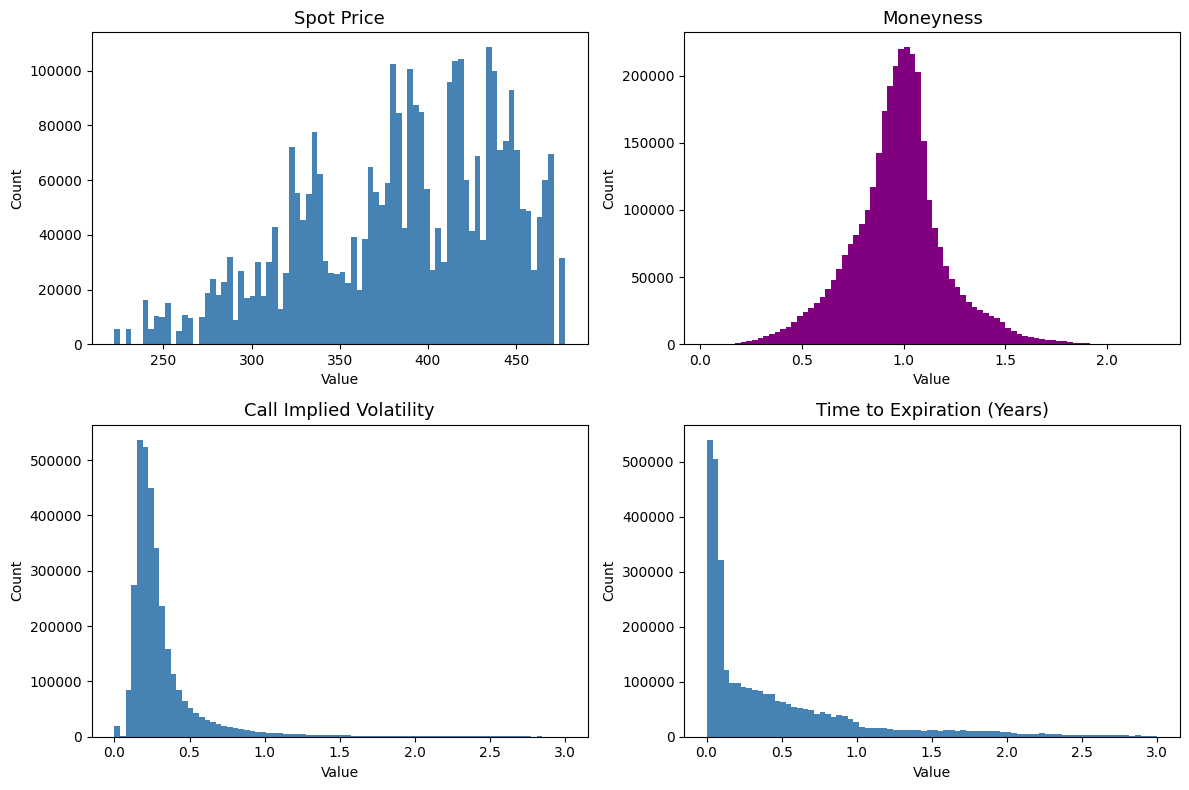

In [12]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0][0].hist(data["UNDERLYING_LAST"].dropna(), bins=80, color="steelblue", edgecolor="none")
axes[0][0].set_title("Spot Price", fontsize=13)
axes[0][0].set_xlabel("Value")
axes[0][0].set_ylabel("Count")

axes[0][1].hist(data["MONEYNESS"].dropna(), bins=80, color="purple", edgecolor="none")
axes[0][1].set_title("Moneyness", fontsize=13)
axes[0][1].set_xlabel("Value")
axes[0][1].set_ylabel("Count")

axes[1][0].hist(data["C_IV"].dropna(), bins=80, color="steelblue", edgecolor="none")
axes[1][0].set_title("Call Implied Volatility", fontsize=13)
axes[1][0].set_xlabel("Value")
axes[1][0].set_ylabel("Count")

axes[1][1].hist(data["DTE_YEARS"].dropna(), bins=80, color="steelblue", edgecolor="none")
axes[1][1].set_title("Time to Expiration (Years)", fontsize=13)
axes[1][1].set_xlabel("Value")
axes[1][1].set_ylabel("Count")



plt.tight_layout()
plt.show()

## Spot Price Distribution
This histogram shows the distribution of underlying asset prices in the real option chain dataset. The data spans a wide range of prices, reflecting the many different market conditions under which options are traded. Understanding the range of underlying prices helps ensure that the synthetic dataset used for model training reflects realistic market scenarios.

## Moneyness Distribution 
This plot shows the distribution of option moneyness, defined as strike price divided by the underlying asset price. The distribution peaks near 1.0, indicating that most traded options are close to at the money, while fewer options exist far in or out of the money.

## Call Implied Volatilty Distribution 
This histogram shows the distribution of implied volatility for call options. Most observations fall in the lower volatility range, with a long tail of higher volatility values representing periods of increased uncertainty or extreme market conditions.

## Time to Expiration 
This histogram shows the distribution of time to expiration in years. Most options have relatively short maturities, while fewer contracts extend to longer expiration horizons.

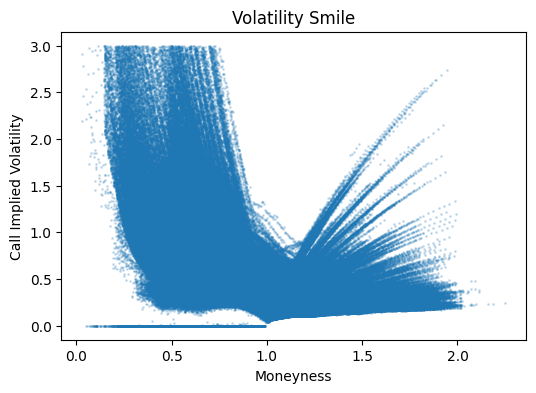

In [13]:
plt.figure(figsize=(6,4))
plt.scatter(data["MONEYNESS"], data["C_IV"], s=1, alpha=0.2)
plt.xlabel("Moneyness")
plt.ylabel("Call Implied Volatility")
plt.title("Volatility Smile")
plt.show()

## Volatility Smile
This scatter plot shows the relationship between moneyness and implied volatility. The curved shape illustrates the well-known volatility smile, where implied volatility tends to be higher for deep in-the-money and out-of-the-money options compared to at-the-money options

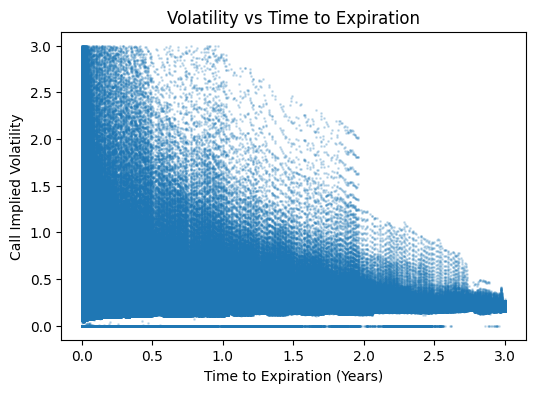

In [14]:
plt.figure(figsize=(6,4))
plt.scatter(data["DTE_YEARS"], data["C_IV"], s=1, alpha=0.2)
plt.xlabel("Time to Expiration (Years)")
plt.ylabel("Call Implied Volatility")
plt.title("Volatility vs Time to Expiration")
plt.show()

## Volatility vs Time to Expiration
This plot shows how implied volatility varies across different times to expiration. Shorter maturities tend to exhibit greater volatility dispersion, while longer maturities show more stable volatility levels.

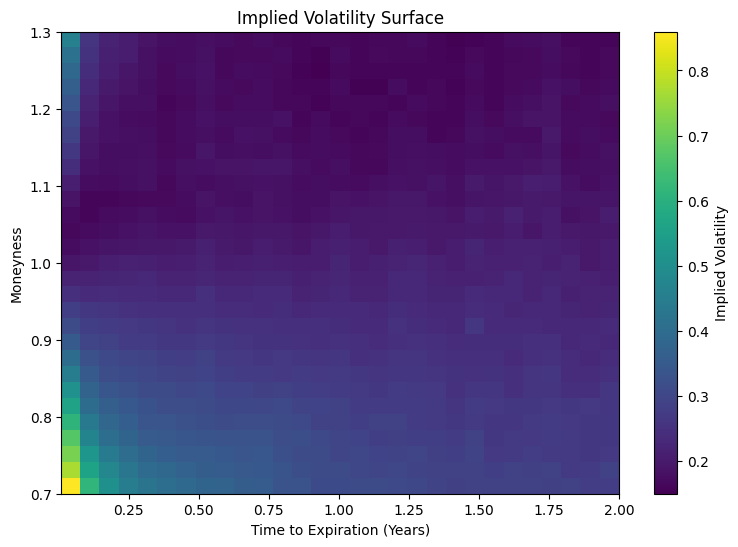

In [15]:
sample = data.sample(200000, random_state=42).copy()

moneyness_bins = np.linspace(0.7, 1.3, 30)
time_bins = np.linspace(0.01, 2.0, 30)

sample["m_bin"] = pd.cut(sample["MONEYNESS"], moneyness_bins)
sample["t_bin"] = pd.cut(sample["DTE_YEARS"], time_bins)

surface = sample.groupby(["m_bin","t_bin"], observed=False)["C_IV"].mean().unstack()

plt.figure(figsize=(9,6))

plt.imshow(
    surface.values,
    aspect="auto",
    origin="lower",
    cmap="viridis",
    extent=[time_bins[0], time_bins[-1], moneyness_bins[0], moneyness_bins[-1]]
)

plt.colorbar(label="Implied Volatility")

plt.xlabel("Time to Expiration (Years)")
plt.ylabel("Moneyness")
plt.title("Implied Volatility Surface")

plt.show()

## Implied Volatility Surface Heatmap
This heatmap visualizes the implied volatility surface across both moneyness and time to expiration. The color intensity represents average implied volatility at each region of the surface, revealing how volatility changes across strike levels and maturities

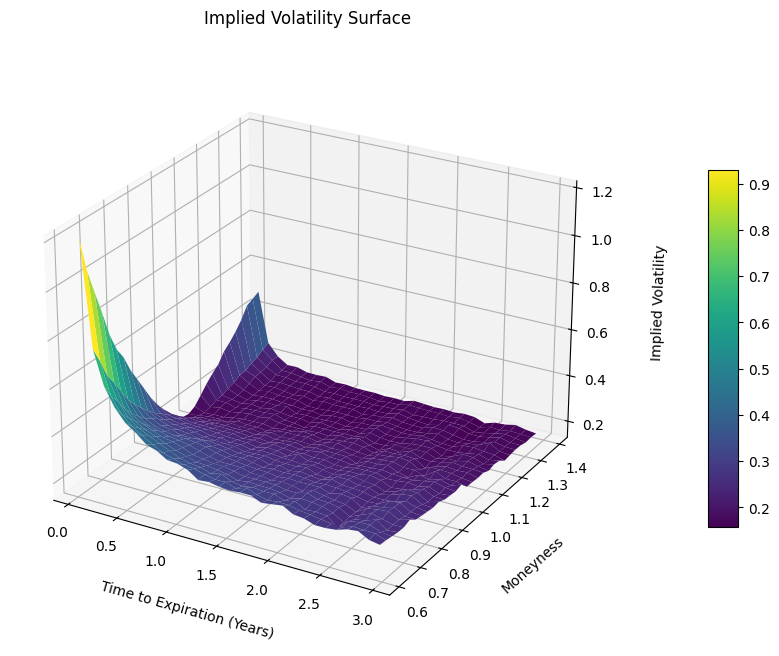

In [16]:
from mpl_toolkits.mplot3d import Axes3D

sample = data.sample(200000, random_state=42).copy()

moneyness_bins = np.linspace(0.6, 1.4, 30)
time_bins = np.linspace(0.01, 3, 30)

sample["m_bin"] = pd.cut(sample["MONEYNESS"], moneyness_bins)
sample["t_bin"] = pd.cut(sample["DTE_YEARS"], time_bins)

surface = sample.groupby(["m_bin", "t_bin"], observed=False)["C_IV"].mean().unstack()

X = np.array([b.mid for b in surface.columns])
Y = np.array([b.mid for b in surface.index])
X, Y = np.meshgrid(X, Y)
Z = surface.values

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(X, Y, Z, cmap="viridis", linewidth=0, antialiased=True)

ax.set_xlabel("Time to Expiration (Years)", labelpad=12)
ax.set_ylabel("Moneyness", labelpad=12)
ax.set_zlabel("Implied Volatility", labelpad=18)

ax.set_title("Implied Volatility Surface", pad=20)

ax.view_init(elev=25, azim=-60)

fig.colorbar(surf, shrink=0.6, aspect=12, pad=0.12)

plt.subplots_adjust(left=0.02, right=0.88, top=0.90, bottom=0.05)
plt.show()

## Implied Volatility Surface 3D
This three-dimensional surface shows the same implied volatility structure across moneyness and time to expiration.

